# Character-Level Text Generation with CNN, LSTM, RNN, and GRU Models

This notebook presents a complete character-level text generation project using multiple deep learning
architectures. The objective is to train neural networks that learn the statistical structure of text and
generate new sequences in the style of *Alice's Adventures in Wonderland*.

## Project Goals
- Build and train several sequence models:
  - **CharCNN** (1D convolutional model)
  - **LSTM** (baseline recurrent model)
  - **Modified LSTM** with variations in:
    - number of layers
    - hidden state dimensionality
    - dropout rates
    - other relevant hyperparameters
  - **RNN** and **GRU** alternatives for comparison

- Construct a character-level dataset using sliding windows of fixed length  
- Train all models using **cross-entropy loss**  
- Evaluate performance using:
  - **Character-level accuracy**
  - **Confusion matrices**
  - **Loss curves and training dynamics**

- Generate new text sequences from each trained model  
- Analyze and compare the generative behavior of CNN, LSTM, RNN, and GRU architectures  

## Key Learning Outcomes
- Understanding how different sequence models handle long-range dependencies  
- Observing the impact of architectural choices on prediction accuracy  
- Using confusion matrices to diagnose model errors  
- Exploring how hyperparameters influence generative quality  
- Gaining practical experience with character-level language modeling  

In [2]:
# Use GPU if available
import torch
train_on_gpu = torch.cuda.is_available()
if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')
device = torch.device("cuda:0" if train_on_gpu else "cpu")
print(device)

CUDA is not available.  Training on CPU ...
cpu


In [3]:
# mount with drive
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [4]:
#change working directory
import os
os.chdir('/content/drive/MyDrive/cnn-lstm-textgen/sequence200/')

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import re

# 1. Load dataset

We are going to use the text of the book "Alice's Adventures in Wonderland" to train our models. We need to download the text and prepare a dataset to load strings to train our models.


In [6]:
# Download the text file "Alice's Adventures in Wonderland" from Project Gutenberg
!wget -O wonderland.txt https://www.gutenberg.org/ebooks/11.txt.utf-8

# Load the text data from the downloaded file
filename = "wonderland.txt"
with open(filename, 'r', encoding='utf-8') as f:
  raw_text = f.read()

# Convert all characters to lowercase
raw_text = raw_text.lower()

# Remove non-alphanumeric characters
raw_text = re.sub(r'\n', ' ', raw_text)
raw_text = re.sub(r'[^A-Za-z ]+', '', raw_text)

print(raw_text[500:700])
# Create a set of unique characters in the text
unique_chars = set(raw_text)

# Sort the unique characters
chars = sorted(list(unique_chars))

# Create a dictionary mapping each unique character to a unique integer
char_to_int = dict((c, i) for i, c in enumerate(chars))

# Split the text into training and testing sets
train_start = int(len(raw_text) * 0.1)  # Starting index for training set (10% of text)
train_end = int(len(raw_text) * 0.8)  # Ending index for training set (80% of text)
test_start = train_end  # Starting index for testing set (remaining 20% of text)

raw_text_train = raw_text[train_start:train_end]  # Extract training text
raw_text_test = raw_text[test_start:]  # Extract testing text

# Calculate and print some summary statistics
n_chars_train = len(raw_text_train)
n_chars_test = len(raw_text_test)
n_vocab = len(chars)

print("Total Characters train:", n_chars_train)
print("Total Characters test:", n_chars_test)
print("Total Unique Characters (Vocabulary Size):", n_vocab)
print("Chars: ",chars)

--2026-05-08 19:38:46--  https://www.gutenberg.org/ebooks/11.txt.utf-8
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: http://www.gutenberg.org/cache/epub/11/pg11.txt [following]
--2026-05-08 19:38:46--  http://www.gutenberg.org/cache/epub/11/pg11.txt
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.gutenberg.org/cache/epub/11/pg11.txt [following]
--2026-05-08 19:38:46--  https://www.gutenberg.org/cache/epub/11/pg11.txt
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 174314 (170K) [text/plain]
Saving to: ‘wonderland.txt’

wonderland.txt      100%[===================>] 170.23K  1012KB/s    in 0.2s   

Prepare the dataset of input to output pairs encoded as integers.
We need to:
1. Convert string of characters to a list of charachter indexes (using the chat_to_ind dictionary previouslty created)
2. Store the list of indexes and the targets in a collection of sequences
3. Prepare the Pytorch Tensors

The model takes input sequences of 100 characters and predicts the character 101

In [7]:
# Define the sequence length for character prediction
seq_length = 200

# List to store sequences of characters as integer indices
dataX = []

# List to store target characters (next character) as integer indices
dataY = []

# Loop through the training text with a stride of 1 character
for i in range(0, n_chars_train - seq_length, 1):
  # Extract an input sequence of length 'seq_length' from the training text
  seq_in = raw_text_train[i:i + seq_length]

  # Extract the target character (next character to predict)
  seq_out = raw_text_train[i + seq_length]

  # Convert characters in the input sequence to their integer indices using the mapping dictionary
  dataX.append([char_to_int[char] for char in seq_in])

  # Append the target character's integer index to the output list
  dataY.append(char_to_int[seq_out])

# Count the total number of training patterns (sequences-target character pairs)
n_patterns = len(dataX)
print("Total Patterns train: ", n_patterns)

# Convert the lists of integer indices (dataX and dataY) into PyTorch tensors
X_train = torch.tensor(dataX, dtype=torch.float32)
y_train = torch.tensor(dataY)

# Reshape the input sequences into a 3D tensor with dimensions:
#   - n_patterns: Number of training patterns
#   - seq_length: Length of the input sequence
#   - 1: Number of features (one-hot encoded characters can be represented as floats here)
X_train = X_train.reshape(n_patterns, seq_length, 1)

# Normalize the input sequences by dividing each element by the vocabulary size
# This helps the training process of the model
X_train = X_train / float(n_vocab)

# Prepare testing data (similar to training data preparation)

y_train = torch.tensor(dataY)

#test
dataX = []
dataY = []
for i in range(0, n_chars_test - seq_length, 1):
    seq_in = raw_text_test[i:i + seq_length]
    seq_out = raw_text_test[i + seq_length]
    dataX.append([char_to_int[char] for char in seq_in])
    dataY.append(char_to_int[seq_out])
n_patterns = len(dataX)
print("Total Patterns test: ", n_patterns)
# Convert the testing data lists to tensors, reshape, normalize, and create target tensor
X_test = torch.tensor(dataX, dtype=torch.float32).reshape(n_patterns, seq_length, 1)
X_test = X_test / float(n_vocab)
y_test = torch.tensor(dataY)

Total Patterns train:  108138
Total Patterns test:  30754


# 2. CNN definition

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class CharCNN(nn.Module):

    def __init__(self, n_vocab):
        super(CharCNN, self).__init__()

        self.conv1 = nn.Conv1d(1, 8, 5)  # First convolutional layer
        self.pool = nn.MaxPool1d(2, 2)  # Max pooling layer
        self.conv2 = nn.Conv1d(8, 16, 5)  # Second convolutional layer
        self.fc1 = nn.Linear(16 * 47, 128)  # First fully-connected layer
        self.fc2 = nn.Linear(128, 64)  # Second fully-connected layer
        self.fc3 = nn.Linear(64, n_vocab)  # Output layer

    def forward(self, x):
        """
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): Input tensor representing the images.

        Returns:
            torch.Tensor: Output tensor representing the class probabilities.
        """
        x = self.pool(F.relu(self.conv1(x)))  # First convolutional layer with ReLU activation and pooling
        x = self.pool(F.relu(self.conv2(x)))  # Second convolutional layer with ReLU activation and pooling
        # print(x.shape)
        x = x.view(x.shape[0],-1)  # Flatten the output from convolutional layers
        # print(x.shape)
        x = F.relu(self.fc1(x))  # First fully-connected layer with ReLU activation
        x = F.relu(self.fc2(x))  # Second fully-connected layer with ReLU activation
        x = self.fc3(x)  # Output layer
        return x

net = CharCNN(n_vocab)

# Create a random input tensor (batch size 128, sequence length 100, feature size 1)
inp = torch.randn(128, 1, 200)

# Run the model with the input tensor and get the output
out = net(inp)

print(out.shape)

torch.Size([128, 27])


# 3. LSTM Model definition.

In [9]:
class CharModel(nn.Module):
  """
  Character-Level Language Model using LSTM.

  This class defines a recurrent neural network (RNN) model with a Long Short-Term Memory (LSTM) layer
  for character-level language modeling.

  Attributes:
      lstm: An LSTM layer with specified input size, hidden size, number of layers, and dropout rate.
      linear: A linear layer to map the LSTM output to the vocabulary size (number of characters).
  """

  def __init__(self, n_vocab):
    """
    Initializes the model with an LSTM layer and a linear layer.

    Args:
        None
    """
    super().__init__()  # Call the superclass constructor

    # Define the LSTM layer
    self.lstm = nn.LSTM(
        input_size=1,  # Input size: one-hot encoded characters (represented as floats here)
        hidden_size=256,  # Hidden size of the LSTM layer
        num_layers=2,  # Number of LSTM layers stacked on top of each other
        batch_first=True,  # Input tensors are of shape (batch_size, seq_len, features)
        dropout=0.2  # Dropout rate for regularization
    )

    # Define the linear layer for output
    self.linear = nn.Linear(256, n_vocab)  # Map LSTM output to vocabulary size (number of characters)

  def forward(self, x):
    """
    Defines the forward pass of the model.

    Args:
        x: A PyTorch tensor of shape (batch_size, seq_len, features) representing the input sequences.

    Returns:
        A PyTorch tensor of shape (batch_size, vocab_size) containing the model's output logits.
    """

    # Pass the input sequence through the LSTM layer
    # The output (`x`) will be a tuple containing the output tensor and the hidden/cell states (not used here)
    x, _ = self.lstm(x)

    # Print the output shape for debugging purposes (can be commented out)
    # print(x.shape)

    # Take only the last output from the sequence (represents the model's prediction based on the entire sequence)
    x = x[:, -1, :]  # Select the last element from the sequence dimension

    # Pass the LSTM output through the linear layer to get logits for the next character prediction
    x = self.linear(x)

    return x

# 3. GRU Model definition.


In [10]:
class CharGRU(nn.Module):
    """
    Character-Level Language Model using GRU.
    """

    def __init__(self, n_vocab, hidden_size=256, num_layers=2, dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.linear = nn.Linear(hidden_size, n_vocab)

    def forward(self, x):
        x, _ = self.gru(x)
        x = x[:, -1, :]       # last timestep
        x = self.linear(x)
        return x


# 4. Vanilla RNN Model Model definition.

In [11]:
class CharRNN(nn.Module):
    """
    Character-Level Language Model using a simple RNN.
    """

    def __init__(self, n_vocab, hidden_size=256, num_layers=2, dropout=0.2):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=dropout
        )

        self.linear = nn.Linear(hidden_size, n_vocab)

    def forward(self, x):
        x, _ = self.rnn(x)
        x = x[:, -1, :]
        x = self.linear(x)
        return x


# 5. Deep LSTM Variant Model Model definition

In [12]:
class CharLSTM_Deep(nn.Module):
    """
    Deeper LSTM with more layers for experimentation.
    """

    def __init__(self, n_vocab, hidden_size=512, num_layers=4, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.linear = nn.Linear(hidden_size, n_vocab)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.linear(x)
        return x

# 6.Small LSTM Variant Model Model definition

In [13]:
class CharLSTM_Small(nn.Module):
    """
    Lightweight LSTM for comparison.
    """

    def __init__(self, n_vocab, hidden_size=128, num_layers=1, dropout=0.1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.linear = nn.Linear(hidden_size, n_vocab)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.linear(x)
        return x


# 7. Bidirectional LSTM Model Model definition

In [14]:
class CharBiLSTM(nn.Module):
    """
    Bidirectional LSTM for richer context representation.
    """

    def __init__(self, n_vocab, hidden_size=256, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.linear = nn.Linear(hidden_size * 2, n_vocab)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.linear(x)
        return x

# Train setup and dataloader

In [15]:
# Hyperparameters for training
n_epochs = 60  # Number of training epochs
batch_size = 128  # Batch size for training

# Create training data loader
loader_train = data.DataLoader(
    data.TensorDataset(X_train, y_train),  # Dataset containing input sequences and target characters
    shuffle=True,  # Shuffle the data for each epoch
    batch_size=batch_size  # Batch size for training
)

# Create testing data loader (without shuffling and with batch size 1 for character-by-character prediction)
loader_test = data.DataLoader(
    data.TensorDataset(X_test, y_test),
    shuffle=False,  # Don't shuffle testing data
    batch_size=1  # Predict character by character for testing
)

# Train the model

In [16]:
from collections import defaultdict
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm

# Storage for metrics
results = defaultdict(lambda: {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "confusion": None
})

In [17]:
def train_model(model, model_name):
    print(f"\n==============================")
    print(f"   Training {model_name}")
    print(f"==============================")

    model.to(device)
    optimizer = optim.Adam(model.parameters())
    loss_fn = nn.CrossEntropyLoss()

    best_loss = np.inf
    patience = 6

    for epoch in range(1, n_epochs + 1):
        print(f"[{model_name}] Epoch {epoch}/{n_epochs} — training…")

        model.train()
        epoch_train_loss = 0

        for X_batch, y_batch in loader_train:

            # CNN FIX: reshape input to (batch, channels, seq_len)
            if model_name == "cnn":
                X_batch = X_batch.permute(0, 2, 1)

            optimizer.zero_grad()
            y_pred = model(X_batch.to(device))
            loss = loss_fn(y_pred, y_batch.to(device))
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        # Store training loss
        results[model_name]["train_loss"].append(epoch_train_loss / len(loader_train))

        # Validation
        model.eval()
        val_losses = []
        val_acc = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X_batch, y_batch in loader_test:

                # CNN FIX for validation too
                if model_name == "cnn":
                    X_batch = X_batch.permute(0, 2, 1)

                y_pred = model(X_batch.to(device))
                loss = loss_fn(y_pred, y_batch.to(device)).cpu()
                val_losses.append(loss.item())

                pred = torch.argmax(y_pred.cpu()).item()
                all_preds.append(pred)
                all_targets.append(y_batch.item())

                val_acc += (pred == y_batch.item())

        val_acc /= len(loader_test)
        avg_val_loss = np.mean(val_losses)

        # Save metrics
        results[model_name]["val_loss"].append(avg_val_loss)
        results[model_name]["val_acc"].append(val_acc)

        # Early stopping + checkpoint
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            patience = 8
            print(f"[{model_name}] **New Best Model Saved**")
        else:
            patience -= 1

        print(f"[{model_name}] Loss={avg_val_loss:.4f} | Acc={val_acc:.4f}")

        if patience <= 0:
            print(f"[{model_name}] Early stopping triggered.")
            break

    # Load best model before computing confusion matrix
    model.load_state_dict(torch.load(f"{model_name}_best.pth"))

    # Recompute predictions for confusion matrix
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader_test:

            if model_name == "cnn":
                X_batch = X_batch.permute(0, 2, 1)

            y_pred = model(X_batch.to(device))
            pred = torch.argmax(y_pred.cpu()).item()
            all_preds.append(pred)
            all_targets.append(y_batch.item())

    cm = confusion_matrix(all_targets, all_preds)
    results[model_name]["confusion"] = cm
    print(f"[{model_name}] Confusion matrix saved.")

In [ ]:
# Train  models 200
models = {

    "lstm": CharModel(n_vocab),
    "bilstm": CharBiLSTM(n_vocab)
}

for name, model in models.items():
    train_model(model, name)


   Training lstm
[lstm] Epoch 1/60 — training…
[lstm] **New Best Model Saved**
[lstm] Loss=2.6255 | Acc=0.2590
[lstm] Epoch 2/60 — training…
[lstm] **New Best Model Saved**
[lstm] Loss=2.4469 | Acc=0.3113
[lstm] Epoch 3/60 — training…
[lstm] **New Best Model Saved**
[lstm] Loss=2.3619 | Acc=0.3382
[lstm] Epoch 4/60 — training…
[lstm] **New Best Model Saved**
[lstm] Loss=2.3417 | Acc=0.3543
[lstm] Epoch 5/60 — training…
[lstm] **New Best Model Saved**
[lstm] Loss=2.3044 | Acc=0.3716
[lstm] Epoch 6/60 — training…
[lstm] **New Best Model Saved**
[lstm] Loss=2.2815 | Acc=0.3833
[lstm] Epoch 7/60 — training…
[lstm] Loss=2.2944 | Acc=0.3774
[lstm] Epoch 8/60 — training…
[lstm] **New Best Model Saved**
[lstm] Loss=2.2759 | Acc=0.3800
[lstm] Epoch 9/60 — training…
[lstm] Loss=2.2924 | Acc=0.3853
[lstm] Epoch 10/60 — training…
[lstm] **New Best Model Saved**
[lstm] Loss=2.2727 | Acc=0.3874
[lstm] Epoch 11/60 — training…
[lstm] Loss=2.2983 | Acc=0.3918
[lstm] Epoch 12/60 — training…
[lstm] Loss

# Test

In [18]:
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(model, weight_path):
    state = torch.load(weight_path, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model


def evaluate_model(model, dataloader, model_name):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:

            # CNN needs (batch, channels, seq_len)
            if model_name == "cnn":
                X_batch = X_batch.permute(0, 2, 1)

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = F.cross_entropy(outputs, y_batch)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)

            total_correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    cm = confusion_matrix(all_targets, all_preds)

    return avg_loss, accuracy, cm



Evaluating cnn...
[cnn] Loss=2.6500 | Acc=0.2567


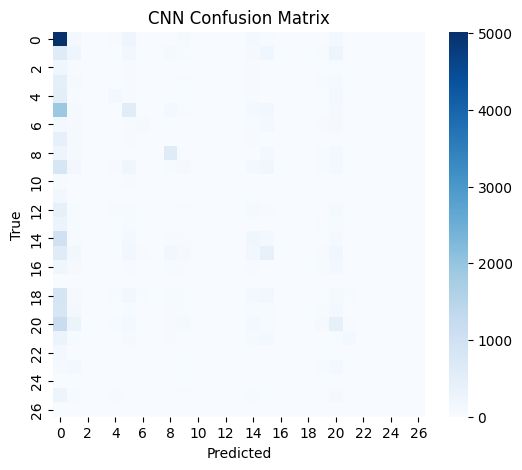


Evaluating lstm...


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Recreate model objects (same definitions as training)
models_eval = {
    "cnn": CharCNN(n_vocab),
    "lstm": CharModel(n_vocab),
    "bilstm": CharBiLSTM(n_vocab)
}

results_eval = {}

for name, model in models_eval.items():
    print(f"\nEvaluating {name}...")

    # Load best weights
    model = load_model(model, f"{name}_best.pth")

    # Evaluate (loss, accuracy, confusion matrix)
    loss, acc, cm = evaluate_model(model, loader_test, name)

    # Store results
    results_eval[name] = {"loss": loss, "acc": acc, "cm": cm}

    # Print metrics
    print(f"[{name}] Loss={loss:.4f} | Acc={acc:.4f}")

    # ---- Plot confusion matrix immediately ----
    cm = np.array(cm)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(f"{name.upper()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [ ]:
# Recreate model objects (same definitions as training)  seq_length = 100
models_eval = {
    "cnn": CharCNN(n_vocab),
    "lstm": CharModel(n_vocab),
    "gru": CharGRU(n_vocab),
    "rnn": CharRNN(n_vocab),
    "lstm_deep": CharLSTM_Deep(n_vocab),
    "lstm_small": CharLSTM_Small(n_vocab),
    "bilstm": CharBiLSTM(n_vocab)
}

results_eval = {}

for name, model in models_eval.items():
    print(f"\nEvaluating {name}...")
    model = load_model(model, f"{name}_best.pth")
    loss, acc, cm = evaluate_model(model, loader_test, name)
    results_eval[name] = (loss, acc, cm)
    print(f"[{name}] Loss={loss:.4f} | Acc={acc:.4f}")
